In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import struct
import matplotlib.pyplot as plt

In [ ]:
with open('/content/drive/MyDrive/AMATH482HW4Data/train-images.idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    print(data.shape)
    Xtraindata = np.transpose(data.reshape((size, nrows*ncols)))

with open('/content/drive/MyDrive/AMATH482HW4Data/train-labels.idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    ytrainlabels = data.reshape((size,)) # (Optional)

with open('/content/drive/MyDrive/AMATH482HW4Data/t10k-images.idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    Xtestdata = np.transpose(data.reshape((size, nrows*ncols)))

with open('/content/drive/MyDrive/AMATH482HW4Data/t10k-labels.idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    ytestlabels = data.reshape((size,)) # (Optional)



traindata_imgs =  np.transpose(Xtraindata).reshape((60000,28,28))
print(Xtraindata.shape)
print(ytrainlabels.shape)
print(Xtestdata.shape)
print(ytestlabels.shape)

(47040000,)
(784, 60000)
(60000,)
(784, 10000)
(10000,)


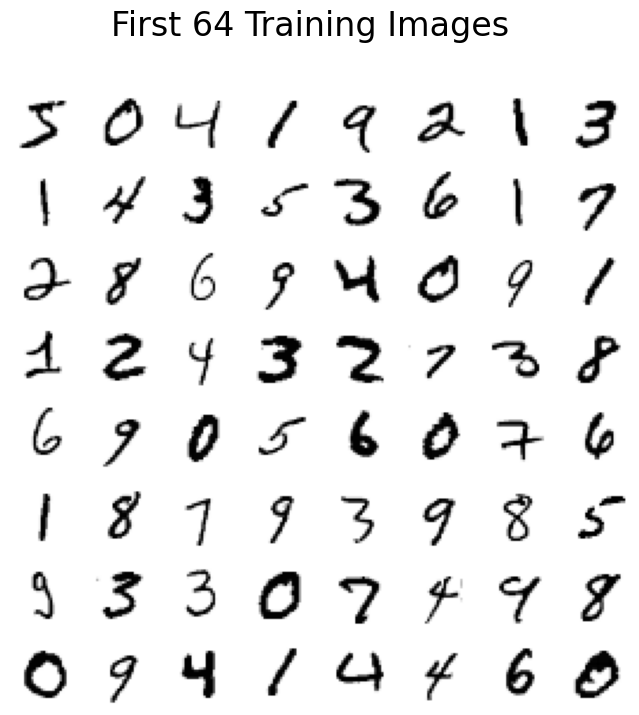

In [ ]:
def plot_digits(XX, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))

    for i in range(N):
      for j in range(N):
        ax[i,j].imshow(XX[:,(N)*i+j].reshape((28, 28)), cmap="Greys")
        ax[i,j].axis("off")
    fig.suptitle(title, fontsize=24)

plot_digits(Xtraindata, 8, "First 64 Training Images" )


In [ ]:
Xtraindata=np.transpose(Xtraindata)
Xtestdata=np.transpose(Xtestdata)
print(Xtraindata.shape)
print(ytrainlabels.shape)
print(Xtestdata.shape)
print(ytestlabels.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


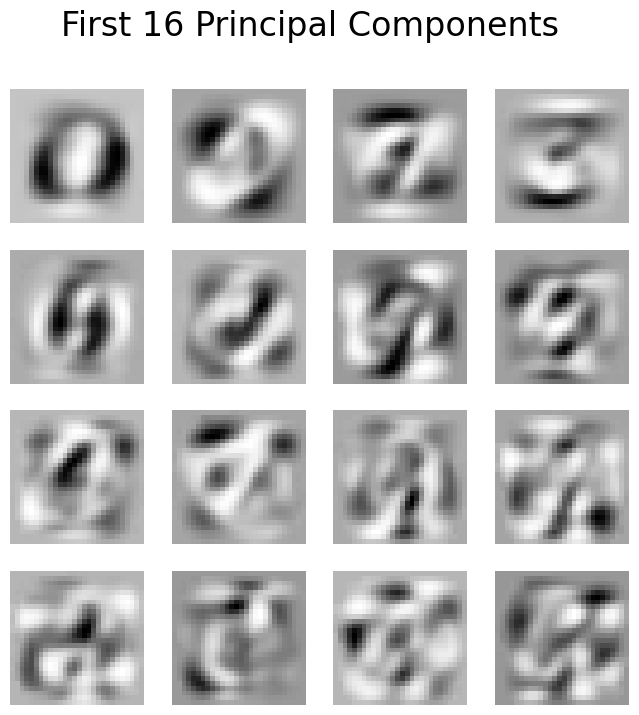

In [ ]:
# 1. Perform PCA analysis of the digit images in the train set. Plot the first 16 PC modes as 28 × 28
# images (see an example on the previous page of how multiple images can be displayed in a grid).

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(Xtraindata)
X_test_scaled = standard_scaler.transform(Xtestdata)

pca = PCA()
pca.fit(X_train_scaled)

PC_modes = pca.components_
singular_values = pca.singular_values_

plot_digits(PC_modes.T, 4, "First 16 Principal Components")

number of PC modes needed to approximate 85% of energy: 185


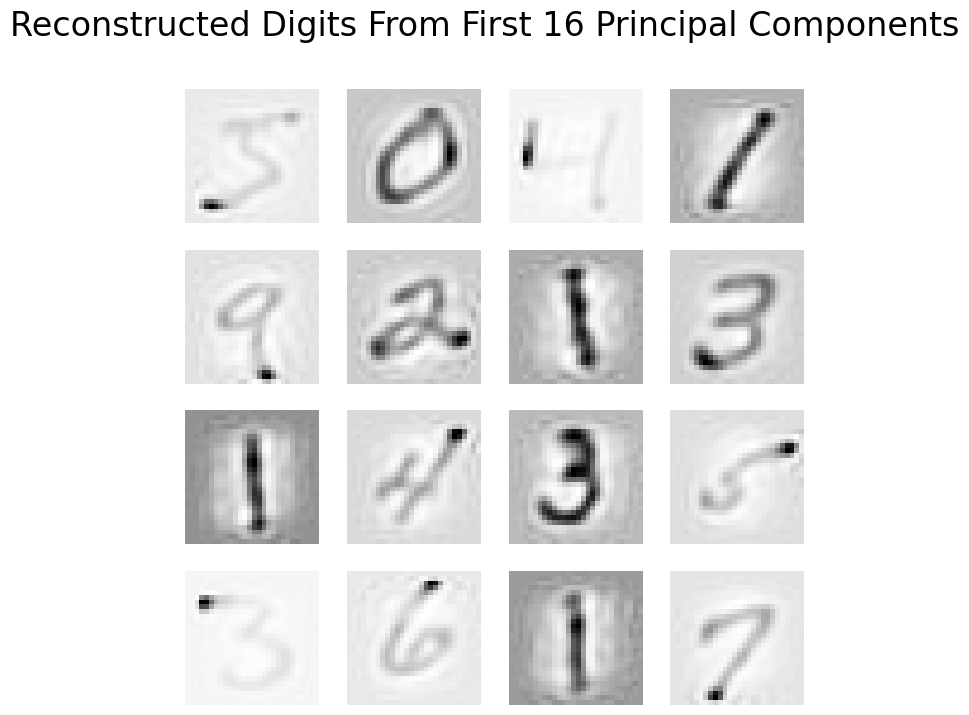

In [ ]:
# 2. Inspect the sum of the squares of the singular values and determine 𝑘: the number of PC modes
# needed to approximate 85% of the squared Frobenius norm. You may also want to inspect several
# approximated digit images reconstructed from 𝑘 truncated PC modes and plot them to make sure that
# the image reconstruction using truncated modes is reasonable.

cumulative_explained = np.cumsum(pca.explained_variance_ratio_)

k = np.argmax(cumulative_explained >= 0.85) + 1
print("number of PC modes needed to approximate 85% of energy:", k)

pca_k = PCA(n_components=k)
X_train_k = pca_k.fit_transform(X_train_scaled)
X_train_reconstructed = pca_k.inverse_transform(X_train_k)

plot_digits(X_train_reconstructed.T, 4, "Reconstructed Digits From First 16 Principal Components")

In [ ]:
# 3. Write a function that selects a subset of particular digits (all samples of them) from 𝑋train, 𝑦train, 𝑋test
# and 𝑦test and returns the subset as new matrices 𝑋subtrain, 𝑦subtrain, 𝑋subtest and 𝑦subtest.

def select_digits(digits_subset, Xtrain, ytrain, Xtest, ytest):
    train_subset = np.isin(ytrain, digits_subset)
    test_subset = np.isin(ytest, digits_subset)

    X_train_subset = Xtrain[train_subset]
    y_train_subset = ytrain[train_subset]
    X_test_subset = Xtest[test_subset]
    y_test_subset = ytest[test_subset]

    return X_train_subset, y_train_subset, X_test_subset, y_test_subset

In [ ]:
# 4. Select the digits 1,8 using step 3, project the data onto 𝑘-PC modes computed in steps 1-2, and apply
# the Ridge classifier (linear) to distinguish between these two digits. Perform cross-validation and
# testing and discuss your results.
#and
# 5. Select the digits 1,8 using step 3, project the data onto 𝑘-PC modes computed in steps 1-2, and apply
# logistic regression to distinguish between these two digits. Do not include a regularization term. Discuss
# your results, and compare with the ridge classifier.
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

def ridge_vs_logistic_results(digits_subset, Xtrain, ytrain, Xtest, ytest):
    X_train_subset, y_train_subset, X_test_subset, y_test_subset = select_digits(digits_subset, Xtrain,
                                                                                 ytrain, Xtest, ytest)
    X_train_subset_pca = pca.transform(X_train_subset)[:, :k]
    X_test_subset_pca = pca.transform(X_test_subset)[:, :k]

    alphas = {'alpha':[10**(-2), 10**(-1), 1, 10, 100]}
    ridge = RidgeClassifier()
    grid = GridSearchCV(ridge, alphas, cv=5, scoring='accuracy')
    grid.fit(X_train_subset_pca, y_train_subset)
    best_ridge_classifier = grid.best_estimator_

    print("Best Alpha:", grid.best_params_['alpha'])

    y_test_predicted = best_ridge_classifier.predict(X_test_subset_pca)
    test_accuracy = accuracy_score(y_test_subset, y_test_predicted)
    print("Ridge Classifier Test accuracy:", test_accuracy)

    logistic_regression_model = LogisticRegression(penalty = None, max_iter = 1000)
    logistic_regression_model.fit(X_train_subset_pca, y_train_subset)

    y_test_predicted = logistic_regression_model.predict(X_test_subset_pca)
    logistic_regression_accuracy = accuracy_score(y_test_subset, y_test_predicted)

    print("Logistic Regression Test Accuracy:", logistic_regression_accuracy)

results_1_8 = ridge_vs_logistic_results([1, 8], X_train_scaled, ytrainlabels, X_test_scaled, ytestlabels)

Best Alpha: 100
Ridge Classifier Test accuracy: 0.9800853485064012
Logistic Regression Test Accuracy: 0.9919393077287814


In [ ]:
# 6. Repeat the same Ridge and logistic classification procedures for pairs of digits 3,8 and 2,7. Report
# your results and compare them with the results in step 4 and 5.

results_3_8 = ridge_vs_logistic_results([3, 8], X_train_scaled, ytrainlabels, X_test_scaled, ytestlabels)
results_2_7 = ridge_vs_logistic_results([2, 7], X_train_scaled, ytrainlabels, X_test_scaled, ytestlabels)

Best Alpha: 1
Ridge Classifier Test accuracy: 0.9606854838709677
Logistic Regression Test Accuracy: 0.9707661290322581
Best Alpha: 100
Ridge Classifier Test accuracy: 0.9791262135922331
Logistic Regression Test Accuracy: 0.9810679611650486


In [ ]:
# 7. Use all the digits and perform multi-class classification with Ridge and KNN classifiers. Report your
# results and discuss how they compare between the methods. Which method performs the best?
# Again, use the data projected onto the 𝑘-PC modes computed in steps 1-2.
from sklearn.neighbors import KNeighborsClassifier

X_train_pca = pca.transform(X_train_scaled)[:, :k]
X_test_pca = pca.transform(X_test_scaled)[:, :k]

results_all = ridge_vs_logistic_results(np.unique(ytrainlabels), X_train_scaled, ytrainlabels, X_test_scaled, ytestlabels)

KNN_param_grid = {'n_neighbors': [1, 3, 5, 7, 9]}
KNN_grid = GridSearchCV(KNeighborsClassifier(), KNN_param_grid, cv=5, scoring='accuracy')
KNN_grid.fit(X_train_pca, ytrainlabels)
KNN_test_accuracy = accuracy_score(ytestlabels, KNN_grid.best_estimator_.predict(X_test_pca))
print("Best k_neighbors:", KNN_grid.best_params_['n_neighbors'])
print("KNN Test accuracy:", KNN_test_accuracy)

Best Alpha: 100
Ridge Classifier Test accuracy: 0.8586
Logistic Regression Test Accuracy: 0.9268
Best k_neighbors: 3
KNN Test accuracy: 0.9548
